In [1]:
# ========================================
# CÉLULA 1: Setup e Imports
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Caminho para os dados
data_dir = Path(r"C:\Users\User\Documents\IA_PROJECT\Archives\Trabalho_IA_2025-fallback_begin\Trabalho_IA_2025-fallback_begin\controllers\youbot\lidar_gps_data")

# Listar arquivos disponíveis
csv_files = sorted(data_dir.glob("*.csv"))
print(f"Arquivos encontrados: {len(csv_files)}")
for i, f in enumerate(csv_files):
    print(f"  [{i}] {f.name}")

Arquivos encontrados: 3
  [0] lidar_gps_20260104_215606.csv
  [1] lidar_gps_20260104_230656.csv
  [2] lidar_gps_20260104_231910.csv


In [2]:
# ========================================
# CÉLULA 2: Carregar e Explorar Dados
# ========================================
# Carregar o arquivo mais recente (ou escolha o índice)
file_idx = 0  # -1 = mais recente, 0 = primeiro, etc.
csv_file = csv_files[file_idx]
print(f"Carregando: {csv_file.name}")

df = pd.read_csv(csv_file)

print(f"\nTotal de amostras: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"\nPrimeiras linhas:")
print(df.head(10))

print(f"\nEstatísticas:")
print(df.describe())

# Contar predições vs skips
predictions = df['inference_time_ms'] > 0
skips = df['inference_time_ms'] == 0
print(f"\nPredições com inferência: {predictions.sum()}")
print(f"Frames pulados: {skips.sum()}")
print(f"Taxa de inferência: {predictions.sum()/len(df)*100:.1f}%")

Carregando: lidar_gps_20260104_215606.csv

Total de amostras: 110598
Colunas: ['tick', 'timestamp', 'x_pred', 'y_pred', 'x_real', 'y_real', 'error_x', 'error_y', 'error_euclidean', 'yaw_cos', 'yaw_sin', 'inference_time_ms', 'smoothed']

Primeiras linhas:
   tick  timestamp    x_pred    y_pred    x_real    y_real   error_x  \
0     0      0.442 -3.610628  1.607172 -3.608830  1.607873 -0.001799   
1     1      0.446 -3.610628  1.607172 -3.607472  1.606568       NaN   
2     2      0.450 -3.610628  1.607172 -3.606032  1.605135       NaN   
3     3      0.453 -3.610628  1.607172 -3.604580  1.603675       NaN   
4     4      0.456 -3.610628  1.607172 -3.603128  1.602213       NaN   
5     5      0.459 -3.610628  1.607172 -3.601678  1.600754       NaN   
6     6      0.462 -3.610628  1.607172 -3.600230  1.599298       NaN   
7     7      0.466 -3.610628  1.607172 -3.598783  1.597846       NaN   
8     8      0.469 -3.610628  1.607172 -3.597339  1.596396       NaN   
9     9      0.471 -3.610

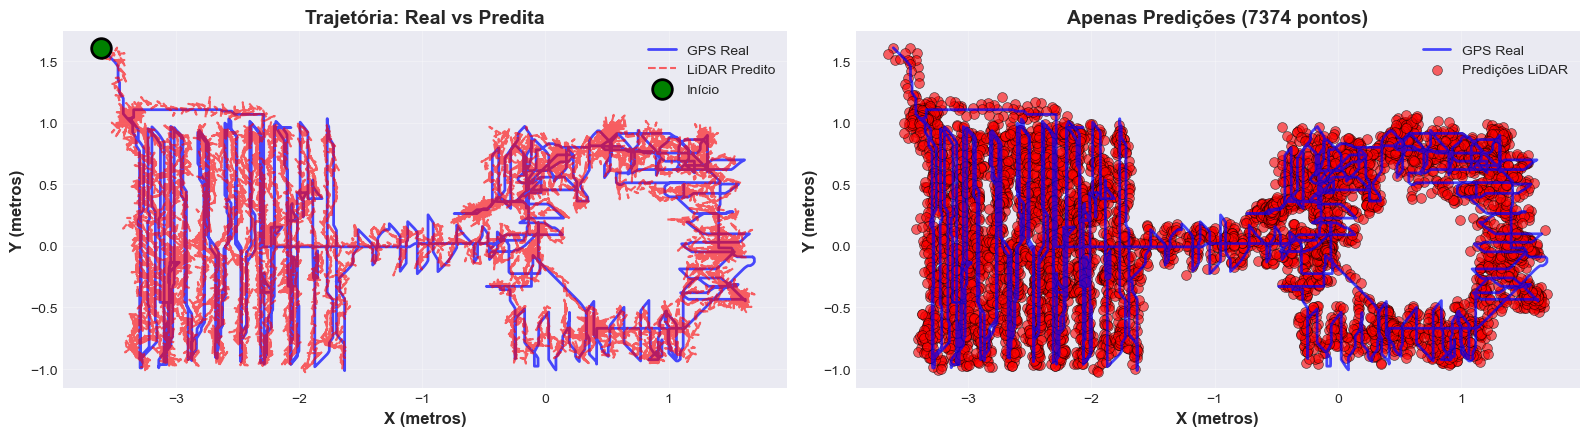

In [5]:
# ========================================
# CÉLULA 3: Trajetória Real vs Predita
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Trajetória completa
ax1 = axes[0]
ax1.plot(df['x_real'], df['y_real'], 'b-', alpha=0.7, linewidth=2, label='GPS Real')
ax1.plot(df['x_pred'], df['y_pred'], 'r--', alpha=0.6, linewidth=1.5, label='LiDAR Predito')
ax1.scatter(df['x_real'].iloc[0], df['y_real'].iloc[0], c='green', s=200, 
           marker='o', edgecolor='black', linewidth=2, label='Início', zorder=5)

ax1.set_xlabel('X (metros)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Y (metros)', fontsize=12, fontweight='bold')
ax1.set_title('Trajetória: Real vs Predita', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Plot 2: Apenas predições (quando houve inferência)
ax2 = axes[1]
df_pred = df[predictions]
if len(df_pred) > 0:
    ax2.plot(df_pred['x_real'], df_pred['y_real'], 'b-', alpha=0.7, linewidth=2, label='GPS Real')
    ax2.scatter(df_pred['x_pred'], df_pred['y_pred'], c='red', s=50, 
               alpha=0.6, edgecolor='black', linewidth=0.5, label='Predições LiDAR')
    ax2.set_xlabel('X (metros)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Y (metros)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Apenas Predições ({len(df_pred)} pontos)', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_42572\1184766083.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=['|Erro X|', '|Erro Y|', 'Erro Euclidiano'],


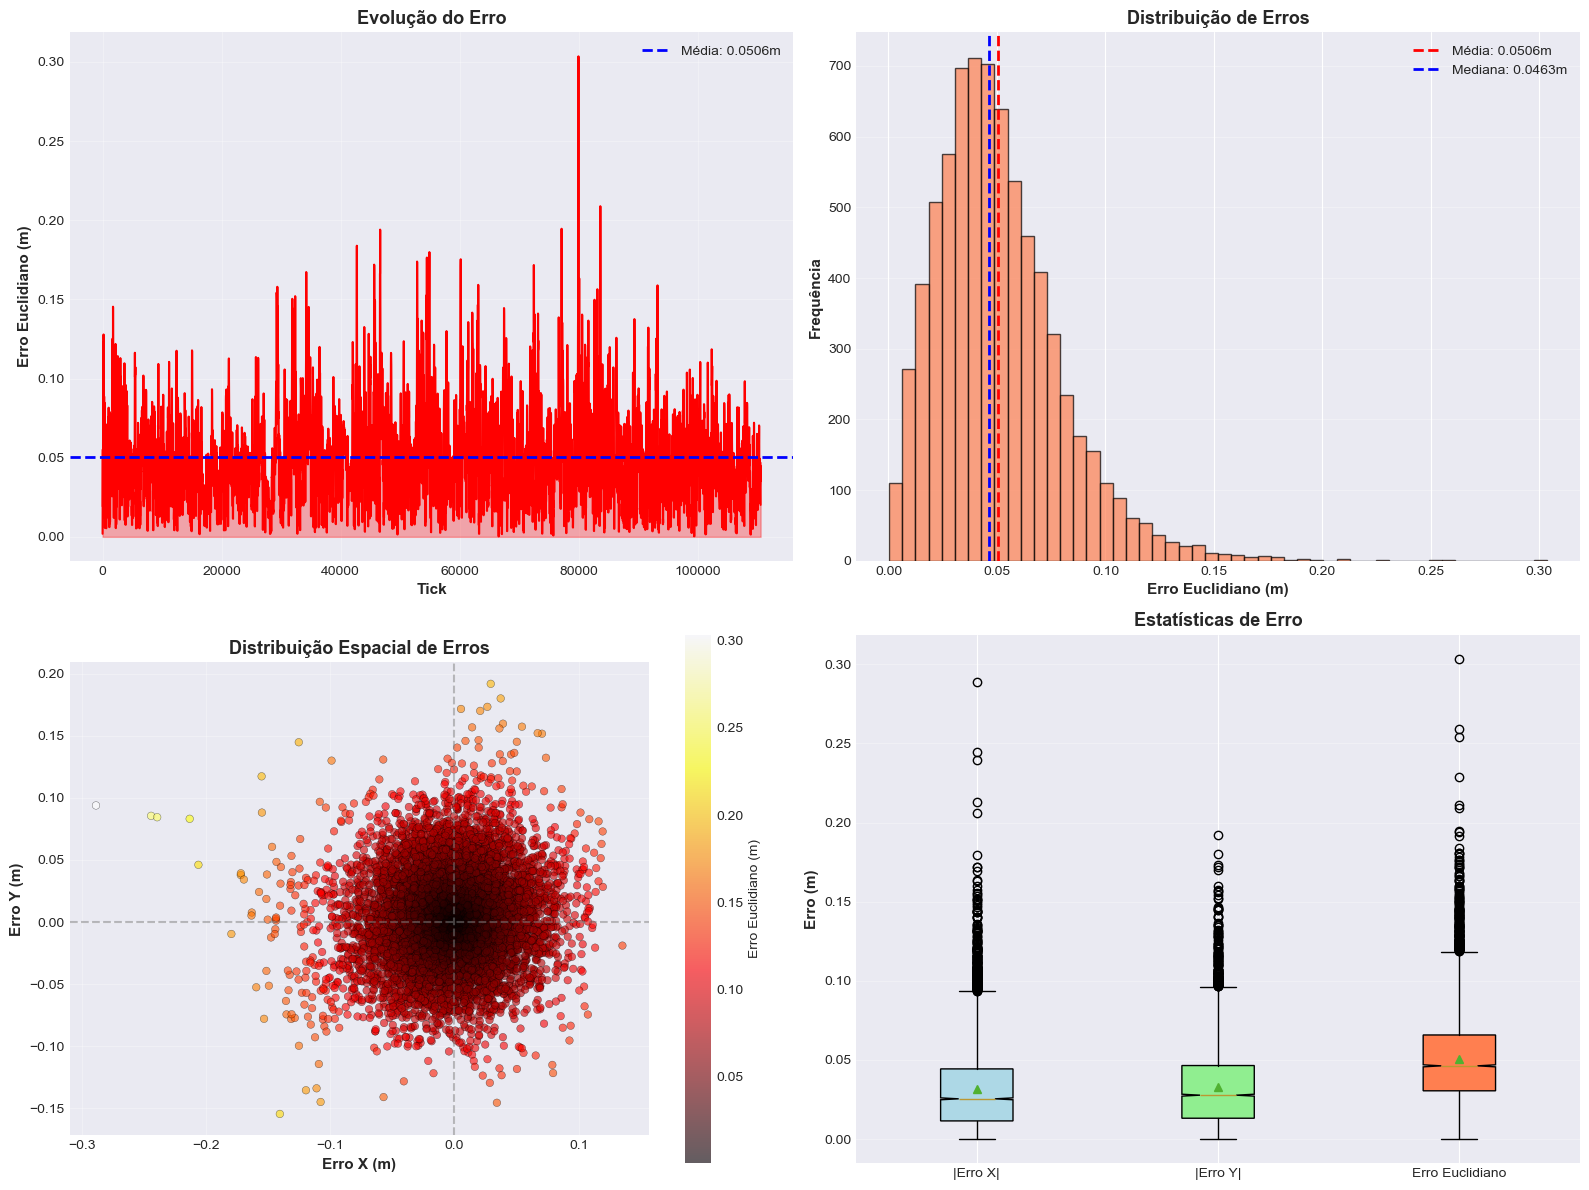


ESTATÍSTICAS DE ERRO
Erro Euclidiano:
  Média:    0.050592 m
  Mediana:  0.046294 m
  Desvio:   0.028712 m
  Mínimo:   0.000272 m
  Máximo:   0.303561 m

Erro X:
  Média:    -0.003790 m
  |Média|:  0.031473 m

Erro Y:
  Média:    0.005153 m
  |Média|:  0.032642 m


In [4]:
# ========================================
# CÉLULA 4: Análise de Erros
# ========================================
# Filtrar apenas onde há erro calculado (predições válidas)
df_errors = df[df['error_euclidean'].notna()]

if len(df_errors) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Erro ao longo do tempo
    ax1 = axes[0, 0]
    ax1.plot(df_errors['tick'], df_errors['error_euclidean'], 'r-', linewidth=1.5)
    ax1.axhline(df_errors['error_euclidean'].mean(), color='blue', linestyle='--', 
               linewidth=2, label=f'Média: {df_errors["error_euclidean"].mean():.4f}m')
    ax1.fill_between(df_errors['tick'], 0, df_errors['error_euclidean'], alpha=0.3, color='red')
    ax1.set_xlabel('Tick', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Erro Euclidiano (m)', fontsize=11, fontweight='bold')
    ax1.set_title('Evolução do Erro', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Histograma de erros
    ax2 = axes[0, 1]
    ax2.hist(df_errors['error_euclidean'], bins=50, color='coral', 
            edgecolor='black', alpha=0.7)
    ax2.axvline(df_errors['error_euclidean'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Média: {df_errors["error_euclidean"].mean():.4f}m')
    ax2.axvline(df_errors['error_euclidean'].median(), color='blue', linestyle='--', 
               linewidth=2, label=f'Mediana: {df_errors["error_euclidean"].median():.4f}m')
    ax2.set_xlabel('Erro Euclidiano (m)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Frequência', fontsize=11, fontweight='bold')
    ax2.set_title('Distribuição de Erros', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Erro X vs Erro Y
    ax3 = axes[1, 0]
    scatter = ax3.scatter(df_errors['error_x'], df_errors['error_y'], 
                         c=df_errors['error_euclidean'], cmap='hot', 
                         s=30, alpha=0.6, edgecolor='black', linewidth=0.3)
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Erro X (m)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Erro Y (m)', fontsize=11, fontweight='bold')
    ax3.set_title('Distribuição Espacial de Erros', fontsize=13, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Erro Euclidiano (m)', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal', adjustable='box')
    
    # Plot 4: Boxplot de erros
    ax4 = axes[1, 1]
    box_data = [df_errors['error_x'].abs(), df_errors['error_y'].abs(), 
                df_errors['error_euclidean']]
    bp = ax4.boxplot(box_data, labels=['|Erro X|', '|Erro Y|', 'Erro Euclidiano'],
                    patch_artist=True, notch=True, showmeans=True)
    colors = ['lightblue', 'lightgreen', 'coral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax4.set_ylabel('Erro (m)', fontsize=11, fontweight='bold')
    ax4.set_title('Estatísticas de Erro', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Estatísticas textuais
    print("\n" + "="*60)
    print("ESTATÍSTICAS DE ERRO")
    print("="*60)
    print(f"Erro Euclidiano:")
    print(f"  Média:    {df_errors['error_euclidean'].mean():.6f} m")
    print(f"  Mediana:  {df_errors['error_euclidean'].median():.6f} m")
    print(f"  Desvio:   {df_errors['error_euclidean'].std():.6f} m")
    print(f"  Mínimo:   {df_errors['error_euclidean'].min():.6f} m")
    print(f"  Máximo:   {df_errors['error_euclidean'].max():.6f} m")
    print(f"\nErro X:")
    print(f"  Média:    {df_errors['error_x'].mean():.6f} m")
    print(f"  |Média|:  {df_errors['error_x'].abs().mean():.6f} m")
    print(f"\nErro Y:")
    print(f"  Média:    {df_errors['error_y'].mean():.6f} m")
    print(f"  |Média|:  {df_errors['error_y'].abs().mean():.6f} m")
else:
    print("AVISO: Nenhuma predição com erro calculado encontrada!")

In [ ]:
# Célula nova: Comparação Raw vs Smoothed
df_with_inference = df[df['inference_time_ms'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot comparando erros
ax1 = axes[0]
data = [df_with_inference['error_euclidean_raw'], 
        df_with_inference['error_euclidean']]
bp = ax1.boxplot(data, labels=['Raw CNN', 'Smoothed (MA)'], patch_artist=True)
ax1.set_ylabel('Erro Euclidiano (m)')
ax1.set_title('Impacto da Média Móvel')

# Histograma
ax2 = axes[1]
ax2.hist(df_with_inference['error_euclidean_raw'], bins=30, alpha=0.6, label='Raw', color='red')
ax2.hist(df_with_inference['error_euclidean'], bins=30, alpha=0.6, label='Smoothed', color='blue')
ax2.set_xlabel('Erro (m)')
ax2.legend()
plt.show()